# Synthetic EUV / AIA — three test datasets

Renders **synthetic SDO/AIA** maps (`I_λ = ∫ n_e² R_λ(T) dℓ`, in DN/s) with the domain-agnostic Siddon integrator `rrt.euv.run_siddon`.

Each test case is defined by a YAML config in `examples/configs/` — the notebook loads the *same* file the CLI does, so `rrt-euv <config>` and this notebook always render the same thing.

| `CASE` | data | config | notes |
|---|---|---|---|
| `case1` | `rho_bin.h5` + `t_bin.h5` | [`case1_euv.yaml`](../configs/case1_euv.yaml) | MAS/PSI full shell, code units, 335 Å, sub-Earth at 2024-03-30 20:49 UTC |
| `case2` | `mhd_data_0220.h5` | [`case2_euv.yaml`](../configs/case2_euv.yaml) | ARMS 90° wedge, density-only → isothermal 1 MK, 171 Å, explicit angles |
| `case3` | `rhoC_02.h5` + `t02.h5` | [`case3_euv.yaml`](../configs/case3_euv.yaml) | MAS/PSI full shell, different snapshot, 171 Å |

**Viewpoints** come from the config's `views:` block. For the Carrington-framed (MAS) cases an `obs_time` gives the sub-Earth L0/B0 via sunpy; the notebook additionally replaces the config's approximate `earth_top` (B0 = 89°) with the exact pole-on view from `rrt.observer.make_earth_top_observer`, which also rotates the image so the Earth direction is +y. The ARMS wedge has no observation time, so it uses explicit `phi_obs_deg` / `B0_deg` angles.

Run it in the `rrt` environment:
```bash
conda activate rrt
python -m ipykernel install --user --name rrt --display-name "Python (rrt)"   # once
jupyter lab examples/notebooks/01_euv_three_viewpoints.ipynb                 # then pick the "Python (rrt)" kernel
```

In [1]:
import os
from pathlib import Path

import numpy as np, matplotlib.pyplot as plt
from rrt.config import load_config, load_cube_from_config
from rrt.observer import (image_grid, make_observer, view_angles,
                          sub_earth_angles, make_earth_top_observer)
from rrt.euv import run_siddon
from rrt.response import load_response
from rrt.viz import aia_cmap, plot_map

# configs use repo-relative paths (data/…), so work from the repo root
REPO = Path.cwd().resolve()
while not (REPO / 'examples' / 'configs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
print('working from:', REPO)

working from: /Users/anshika/Desktop/rrt_final test


## 1. Pick the test case

Change `CASE` and re-run everything below. Always read the printed `cube.summary()` — check the detected `case` / `fmt` and the `ne` / `T` ranges before trusting the image.

In [8]:
CASE = 'case3'          # 'case1' | 'case2' | 'case3'

CONFIGS = {
    'case1':    'examples/configs/case1_euv.yaml',
    'case2': 'examples/configs/case2_euv.yaml',
    'case3':    'examples/configs/case3_euv.yaml',
}
# fixed log color limits [DN/s] per case; None → joint 50–99.9 percentile
VLIMS = {
    'case1':    (10**-0.5, 10**3.0),   # matches the PSI reference colorbar
    'case2': (1e0, 1e5),
    'case3':    (1e-1, 1e4),
}
VLIM = VLIMS[CASE]
ADD_EARTH_TOP = True      # exact pole-on view (MAS cases only; needs an obs_time)
MASK_DISK = False         # True → coronagraph style (hide on-disk pixels)

cfg = load_config(CONFIGS[CASE])
cube = load_cube_from_config(cfg)
print(cube.summary())
r, th, ph, ne, T = cube.r, cube.theta, cube.phi, cube.ne, cube.T

T_resp, R_resp = load_response(cfg.response, cfg.wavelength)

# ---- viewpoints, straight from the config ----
VIEWS = {v['label']: make_observer(*view_angles(v)) for v in cfg.views}
OBS_TIME = next((v.get('obs_time') for v in cfg.views if v.get('obs_time')), '')
if OBS_TIME and ADD_EARTH_TOP:
    # replace the config's B0=89 approximation with the exact pole-on view
    VIEWS['earth_top'] = make_earth_top_observer(OBS_TIME, pole='north')
    L0, B0 = sub_earth_angles(OBS_TIME)
    print(f'sub-Earth at {OBS_TIME}:  L0 = {L0:.2f} deg (Carrington),  B0 = {B0:+.2f} deg')
print(f'{CASE}: AIA {cfg.wavelength} Å, {cfg.Npix}² px, Rmax = {cfg.Rmax} R_sun, '
      f'views = {list(VIEWS)}')

MHDCube  case=separate  fmt=mas
  r     : 1.031 – 4.932 R_sun  (n=139)
  theta : -1.1 – 181.1 deg  (n=143)
  phi   : -0.6 – 360.6 deg  (n=300)
  ne    : 3.12e+03 – 2.67e+09 cm^-3   shape=(139, 143, 300)
  T     : 1.60e+05 – 3.16e+06 K   [K]
sub-Earth at 2024-05-08T14:09:00:  L0 = 332.23 deg (Carrington),  B0 = -3.35 deg
rhoC_02: AIA 171 Å, 256² px, Rmax = 1.5 R_sun, views = ['earth', 'earth_top']


## 2. Ray-trace AIA DN/s per viewpoint

Passing the real `(T_resp, R_resp)` makes `run_siddon` return AIA DN/s directly (temperature-weighted), so cool dense plasma is suppressed. Use `FLAT_T, FLAT_R` from `rrt.response` instead if you want raw column EM. For `arms_wedge` the cube is isothermal, so `R(T)` is a constant and the map traces `∫n_e²dℓ` alone. The first call spends ~5–10 s in the numba JIT; later calls take well under a second.

In [9]:
Xg, Yg, _ = image_grid(cfg.Rmax, cfg.Npix)
images = {}
for label, (n_obs, e_los, x_img, y_img) in VIEWS.items():
    print(f'--- {label} ---')
    images[label] = run_siddon(Xg, Yg, x_img, y_img, e_los, r, th, ph, ne, T,
                               T_resp, R_resp, Npix=cfg.Npix, Rmax=cfg.Rmax,
                               WAVELENGTH=cfg.wavelength, OBS_TIME=OBS_TIME,
                               plot=False, save=False)

--- earth ---
Domain: r=[1.031, 4.985] R_sun, theta full, phi full (360.0 deg)
Warming up Numba JIT (first call compiles, ~10 s)...
Running Siddon integration (256×256 pixels)...
Done in 1.2 s  |  I_min=1.14e-01  I_max=8.07e+03 DN/s/pix
--- earth_top ---
Domain: r=[1.031, 4.985] R_sun, theta full, phi full (360.0 deg)
Warming up Numba JIT (first call compiles, ~10 s)...
Running Siddon integration (256×256 pixels)...
Done in 0.9 s  |  I_min=2.40e-01  I_max=1.04e+04 DN/s/pix


## 3. AIA-styled figure

`sdoaia` colormap, shared log color limits (so nothing saturates and the panels are directly comparable), limb wireframe, optional disk mask. Files are written to the config's `output_dir` with an `nb_` prefix, so they never overwrite what `rrt-euv` writes.

wrote → out/case3_euv


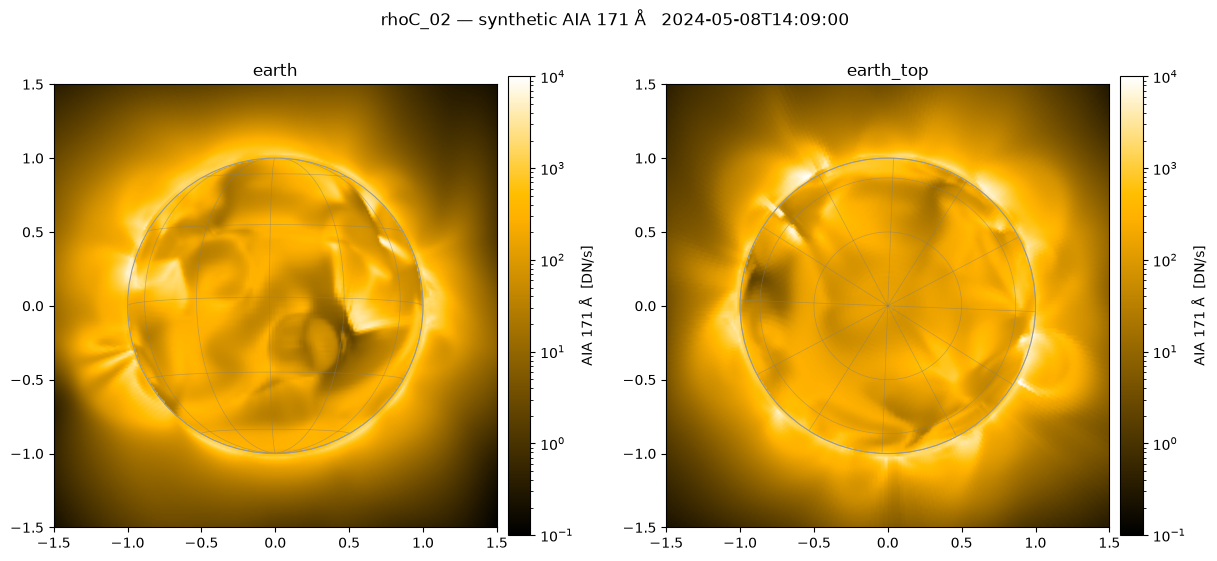

In [10]:
OUT_DIR = Path(cfg.output_dir); OUT_DIR.mkdir(parents=True, exist_ok=True)
slug = lambda s: ''.join(c if c.isalnum() else '_' for c in s).strip('_').lower()

if VLIM is None:   # shared limits from the joint 50–99.9 percentile
    allpix = np.concatenate([im[im > 0].ravel() for im in images.values()])
    vlo, vhi = np.nanpercentile(allpix, [50, 99.9])
else:
    vlo, vhi = VLIM

fig, axes = plt.subplots(1, len(VIEWS), figsize=(6.2 * len(VIEWS), 5.4))
for ax, (label, (n_obs, e_los, x_img, y_img)) in zip(np.atleast_1d(axes), VIEWS.items()):
    plot_map(images[label], cfg.Rmax, cmap=aia_cmap(cfg.wavelength), log=True,
             mask_disk=MASK_DISK, vlim=(vlo, vhi),
             wireframe=(n_obs, x_img, y_img),
             cbar_label=f'AIA {cfg.wavelength} Å  [DN/s]', title=label, ax=ax)
    # ...and a stand-alone PNG per view
    f1, _, _ = plot_map(images[label], cfg.Rmax, cmap=aia_cmap(cfg.wavelength), log=True,
                        mask_disk=MASK_DISK, vlim=(vlo, vhi),
                        wireframe=(n_obs, x_img, y_img),
                        cbar_label=f'AIA {cfg.wavelength} Å  [DN/s]',
                        title=f'{CASE} · {label} — AIA {cfg.wavelength} Å  {OBS_TIME}')
    f1.savefig(OUT_DIR / f'nb_euv_{cfg.wavelength}_{slug(label)}.png', dpi=150, bbox_inches='tight')
    plt.close(f1)

fig.suptitle(f'{CASE} — synthetic AIA {cfg.wavelength} Å   {OBS_TIME}', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / f'nb_euv_{cfg.wavelength}_all_views.png', dpi=150, bbox_inches='tight')
print('wrote →', OUT_DIR)
plt.show()